In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
from typing import Optional

In [2]:
from treasury_ml_utils.snowflake_utils import SnowflakeConnector

snowflake_client = SnowflakeConnector("joshua.choy@transferwise.com")

Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://transferwise.okta-emea.com/app/snowflake/exk4istpb5gZUyV8u0i7/sso/saml?SAMLRequest=nZLBctowEIZfxaOebckuENAAGRo3DTNpS8CETm6KvRDFsuRq5RjevsKETnpIDr155G9X3%2Brf8eW%2BUsELWJRGT0gcMRKAzk0h9W5C1tl1OCQBOqELoYyGCTkAksvpGEWlaj5r3JNewu8G0AW%2BkUbe%2FZiQxmpuBErkWlSA3OV8Nft%2By5OI8doaZ3KjyJuSjysEIljnDc8lBUqv9%2BRczSlt2zZqP0fG7mjCGKNsRD11RD6d%2Bb2f6R0%2Bpqx35D3h8cWr2xepT0%2FwkdbjCUJ%2Bk2WLcPFzlZFgdla9MhqbCuwK7IvMYb28PQmgN1hmyUUvGUbQhDloZ4UK4wi1abdKlJCbqm6cbxz5L7qFgiqzk372eTohdSmLeam3yWJvn%2B%2FS4Z34ddOUz5t26YqNiOVgEw9Mtvy2TpM0zb%2FmJLg%2Fh5scw50jNjDXx0idP2LJIGRJGI8yNuBxj7N%2BNOqPHkiQ%2BkilFq6rPHt7U41bsK1EiEzpRAgViE5T1DX9OwGFfdmT6OrH%2Fu5hfbgfNkxeUERDj1mT0%2FrwTsVO%2F%2BNRxvRtg9dl%2FOHzmacLo2R%2BCK6NrYR7P744irsTWYTbDuVQCalmRWEB0ceolGmvLAjnd97ZBgid

In [3]:
ccy_df = snowflake_client.fetch(f"""
WITH RankedRows AS 
  (SELECT *,
          ROW_NUMBER() OVER (
           PARTITION BY ccypair
                             ORDER BY lastupdatedat DESC) AS rn
   FROM rate_live.provider_config)
   
SELECT DISTINCT ccypair,
                activeprovider,
                providers,
                lastupdatedat
FROM RankedRows
WHERE rn = 1
ORDER BY ALL
""")

elektron_df = snowflake_client.fetch(f"""
SELECT DISTINCT 
   CCY_PAIR,
   RIC,
   TENOR
FROM 
    rate_connector_elektron.instrument_fx_outright_history
    where TENOR in ('SP','ON','TN')
    order by all
""")

bbg_df = snowflake_client.fetch(f"""
SELECT 
    ccy_pair,
    MAX_BY(ticker, update_timestamp) as ticker,
    MAX_BY(tenor, update_timestamp) as tenor,
    MAX(update_timestamp) as latest_ts
FROM rate_connector_bloomberg_kafka.streamingengine_rate_connector_bloomberg_market_data_fx_outright_protobuf
WHERE tenor IN ('SP', 'ON', 'TN')
GROUP BY ccy_pair
order by ccy_pair
""")

In [22]:
currencies = ['USDINR', 'USDIDR', 'USDMYR', 'USDPHP', 'USDKRW', 'USDTWD', 'USDVND', 'USDNPR', 'USDBDT', 'USDLKR', 'USDPKR', 'USDCNY', 'USDTHB']

ccy_df[ccy_df['ccypair'].isin(currencies)].sort_values(by='ccypair', ascending=True)

,ccypair,activeprovider,providers,lastupdatedat
34,USDBDT,REUTERS_ELEKTRON,"REUTERS_ELEKTRON,BLOOMBERG,XE",2025-05-28 15:40:18.360
50,USDCNY,XE,"BLOOMBERG,XE,REUTERS_ELEKTRON",2026-02-15 20:00:12.563
74,USDIDR,BLOOMBERG,"BLOOMBERG,REUTERS_ELEKTRON,XE",2026-02-17 01:38:53.102
77,USDINR,REUTERS_ELEKTRON,"BLOOMBERG,REUTERS_ELEKTRON,XE",2026-02-18 21:02:30.060
90,USDKRW,BLOOMBERG,"BLOOMBERG,REUTERS_ELEKTRON,XE",2026-02-15 22:16:08.681
96,USDLKR,REUTERS_ELEKTRON,"REUTERS_ELEKTRON,BLOOMBERG,XE",2026-02-19 03:36:51.601
112,USDMYR,REUTERS_ELEKTRON,"REUTERS_ELEKTRON,BLOOMBERG,XE",2026-02-18 23:43:24.762
117,USDNPR,REUTERS_ELEKTRON,"REUTERS_ELEKTRON,BLOOMBERG,XE",2025-05-28 15:44:59.699
121,USDPHP,BLOOMBERG,"BLOOMBERG,REUTERS_ELEKTRON,XE",2026-02-15 22:35:23.175
122,USDPKR,BLOOMBERG,BLOOMBERG,2025-08-25 13:35:12.963


In [23]:
elektron_df[(elektron_df['ccy_pair'].isin(currencies)) & (elektron_df['tenor'] == 'SP')]

,ccy_pair,ric,tenor
66,USDBDT,BDT=,SP
94,USDCNY,CNY=,SP
133,USDIDR,IDR=,SP
139,USDINR,INR=,SP
159,USDKRW,KRW=,SP
169,USDLKR,LKR=,SP
199,USDMYR,MYR=,SP
208,USDNPR,NPR=,SP
215,USDPHP,PHP=,SP
216,USDPKR,PKR=PK,SP


In [24]:
bbg_df[bbg_df['ccy_pair'].isin(currencies)]

,ccy_pair,ticker,tenor,latest_ts
93,USDBDT,USDBDT Curncy,SP,2026-02-19 05:33:18
110,USDCNY,USDCNY CMPN Curncy,SP,2026-02-13 18:59:59
140,USDIDR,USDIDR CMPN Curncy,SP,2026-02-19 06:14:51
143,USDINR,USDINR CMPN Curncy,SP,2026-02-18 18:01:45
155,USDKRW,USDKRW CMPN Curncy,SP,2026-02-19 06:14:58
161,USDLKR,USDLKR Curncy,SP,2026-02-19 06:13:59
178,USDMYR,USDMYR Curncy,SP,2026-02-19 06:14:58
184,USDNPR,USDNPR Curncy,SP,2026-02-18 17:01:51
190,USDPHP,USDPHP CMPN Curncy,SP,2026-02-19 06:14:56
191,USDPKR,USDPKR CMPN Curncy,SP,2026-02-19 06:13:59


In [9]:
def filter_df(df, day_of_week:int, hour_of_day:int, ccy: Optional[str] = None):
    '''
    :param df: dataframe of exposure data
    :param day_of_week: int to represent day of week, Mon = 0 and Sun = 6
    :param hour_of_day: hour of day in UTC
    :param ccy: (Optional) ccy code in string format (e.g 'VND')
    '''
    mask = (
        (df['hour_timestamp'].dt.dayofweek == day_of_week) & 
        (df['hour_timestamp'].dt.hour == hour_of_day) 
        #(df['ccy'] == ccy )
    )

    if ccy is not None:
        mask = mask & (df['ccy'] == ccy)

    return df.loc[mask].sort_values(by='hour_timestamp')

In [10]:
def calc_statistics(df, ccy:str):
    '''
    :param df: dataframe to calculate on
    :param ccy: string of ccy that we are measuring on
    '''

    ccy_df = df.loc[df['ccy'] == ccy]
    ccy_stats  = ccy_df.groupby('ccy').agg(
        avg_usd_exposure = ('position_in_USD', 'mean'),
        sd_exposure = ('position_in_USD', 'std'),
        avg_pnl = ('total_fx_pnl', 'mean'),
        worst_loss = ('total_fx_pnl', 'min'),
        sd_pnl = ('total_fx_pnl', 'std')

    )

    return ccy_stats

In [12]:
monday_df = filter_df(df, 0, 0)
monday_df['abs_position_USD'] = monday_df['position_in_USD'].abs()
monday_df.sort_values('abs_position_USD', ascending=False).head()

,ccy,hour_timestamp,hour_position,rate_to_usd,rate_to_gbp,total_fx_pnl,usd_rate,gbp_rate,position_in_USD,position_in_GBP,abs_position_USD
113676,INR,2025-09-01,-4.109559e+09,0.011341,0.008399,41196.473389,88.174091,119.066046,-4.660733e+07,-3.451495e+07,4.660733e+07
96056,IDR,2025-03-31,7.641236e+11,0.000060,0.000047,-76352.894004,16556.291391,21413.276231,4.615306e+07,3.568457e+07,4.615306e+07
24700,PHP,2025-12-08,2.508880e+09,0.016958,0.012726,-16444.894062,58.969566,78.579904,4.254534e+07,3.192776e+07,4.254534e+07
24067,INR,2026-01-26,-3.854437e+09,0.010908,0.007983,8888.483584,91.674994,125.259914,-4.204459e+07,-3.077152e+07,4.204459e+07
105119,THB,2025-10-20,-1.317174e+09,0.030465,0.022692,5168.697382,32.824984,44.069171,-4.012719e+07,-2.988879e+07,4.012719e+07


In [13]:
def scatterplot(df, day_of_week:int, hour_of_day:int):
    '''
    :param: df: dataframe containing snap data from grafana
    :day_of_week: integer of day, 0 = Monday
    :hour_of_day: integer of hour, 0 = midnight UTC
    '''

    filtered_df = filter_df(df, day_of_week=day_of_week, hour_of_day=hour_of_day)
    plt.figure(figsize=(12, 6))

    # Plotting only the Monday 8am Slice
    sns.scatterplot(
        data=filtered_df,
        x='position_in_USD', # Use signed position to see Direction (Long/Short)
        y='total_fx_pnl',
        hue='ccy',           # Color by currency     # Dot size = Size of the PnL impact
        sizes=(50, 400),
        alpha=0.75
    )

    day_dict = {0:'Monday', 1: "Tuesday", 2:"Wednesday", 3:"Thursday", 4:"Friday"}

    plt.title(f'{day_dict[day_of_week]} {hour_of_day + 8} SGP: Exposure vs. PnL Impact')
    plt.xlabel('Position in USD (Left=Short, Right=Long)')
    plt.ylabel('Total FX PnL')
    plt.axhline(0, color='black', linewidth=1) # Zero PnL line
    plt.axvline(0, color='black', linewidth=1) # Zero Position line
    plt.grid(True, linestyle='--', alpha=0.5)
    
    return plt.show()


def scatterplot_interactive(df, day_of_week:int, hour_of_day:int):
    '''
    :param: df: dataframe containing snap data from grafana
    :day_of_week: integer of day, 0 = Monday
    :hour_of_day: integer of hour, 0 = midnight UTC
    '''

    df['hour_timestamp'] = pd.to_datetime(df['hour_timestamp'])
    filtered_df = filter_df(df, day_of_week=day_of_week, hour_of_day=hour_of_day)
    filtered_df['date_str'] = filtered_df['hour_timestamp'].dt.strftime('%Y-%m-%d')

    day_dict = {0:'Monday', 1: "Tuesday", 2:"Wednesday", 3:"Thursday", 4:"Friday"}

    fig = px.scatter(
    filtered_df,
    x='position_in_USD',
    y='total_fx_pnl',
    color='ccy',                 # Different color per currency
    size=filtered_df['total_fx_pnl'].abs(), # Bubble size based on PnL magnitude
    hover_name='ccy',            # Title of the tooltip
    hover_data={                 # Customizing what shows up when you hover
        'date_str': True,
        'position_in_USD': ':,.0f', # Format with commas
        'total_fx_pnl': ':,.2f',    # Format with 2 decimals
        'usd_rate': ':.6f',      # Show the rate used
        'ccy': False,               # Already in title
        'hour_timestamp': False     # Replaced by date_str
    },
    title=f'{day_dict[day_of_week]} {hour_of_day+8} SGP Exposure vs. PnL Impact',
    template='plotly_white',      # Clean background
    height=600                    # Taller chart
)

    fig.add_hline(y=0, line_width=1, line_dash="solid", line_color="black", opacity=0.5)
    fig.add_vline(x=0, line_width=1, line_dash="solid", line_color="black", opacity=0.5)
    return fig.show()

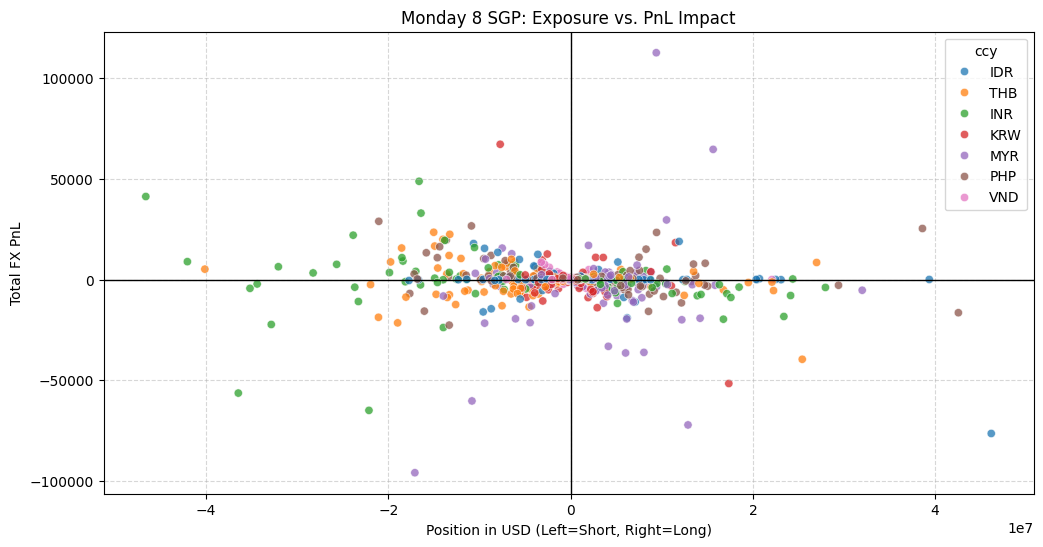

In [14]:
scatterplot(df, 0, 0)

In [16]:
scatterplot_interactive(df, 0, 0)

In [17]:
# get largest change in exposure from Fri NYK close to Monday open
# get largest rate change for this weekend gap

mask_open = ((df['hour_timestamp'].dt.dayofweek ==0 ) & (df['hour_timestamp'].dt.hour == 0))
mask_close = ((df['hour_timestamp'].dt.dayofweek ==4 ) & (df['hour_timestamp'].dt.hour.isin([22])))
filtered_df = df[mask_open | mask_close]
filtered_df.sort_values(['hour_timestamp', 'ccy'])
filtered_df

,ccy,hour_timestamp,hour_position,rate_to_usd,rate_to_gbp,total_fx_pnl,usd_rate,gbp_rate,position_in_USD,position_in_GBP
563,PHP,2024-04-15 00:00:00,1.231242e+08,0.017679,0.014188,721.232766,56.564925,70.482594,2.176688e+06,1.746874e+06
564,THB,2024-04-15 00:00:00,8.861963e+07,0.027297,0.021907,-2945.571959,36.634062,45.647718,2.419050e+06,1.941381e+06
1039,KRW,2024-04-08 00:00:00,-1.769264e+09,0.000740,0.000586,2525.636502,1350.621286,1705.029838,-1.309963e+06,-1.037673e+06
1071,MYR,2024-04-15 00:00:00,7.556030e+07,0.209622,0.168229,-2786.672450,4.770492,5.944278,1.583910e+07,1.271143e+07
1072,IDR,2024-04-15 00:00:00,4.861159e+10,0.000063,0.000051,4930.642091,15847.860539,19762.845850,3.067391e+06,2.459746e+06
...,...,...,...,...,...,...,...,...,...,...
129020,PHP,2026-01-09 22:00:00,5.449021e+08,0.016874,0.012591,-10.265172,59.263122,79.424332,9.194624e+06,6.860645e+06
129021,MYR,2026-01-09 22:00:00,1.809794e+07,0.245489,0.183174,164.657197,4.073502,5.459290,4.442844e+06,3.315071e+06
129313,IDR,2026-01-09 22:00:00,1.411662e+11,0.000059,0.000044,3.981602,16835.016835,22573.363431,8.385275e+06,6.253664e+06
129707,INR,2026-01-09 22:00:00,3.671171e+09,0.011081,0.008268,-20.658363,90.243748,120.943846,4.068061e+07,3.035434e+07


In [18]:
pos_df = filtered_df.sort_values(by=['ccy', 'hour_timestamp'])
pos_df['change_usd_exposure'] = pos_df.groupby('ccy')['position_in_USD'].diff()
pos_df['abs_change_usd'] = pos_df['change_usd_exposure'].abs()
pos_df

,ccy,hour_timestamp,hour_position,rate_to_usd,rate_to_gbp,total_fx_pnl,usd_rate,gbp_rate,position_in_USD,position_in_GBP,change_usd_exposure,abs_change_usd
90783,IDR,2024-01-01 00:00:00,1.133528e+11,0.000065,0.000051,-27.388748,15408.320493,19607.843137,7.356597e+06,5.780993e+06,NaN,NaN
67047,IDR,2024-01-05 22:00:00,1.106494e+11,0.000064,0.000051,56.562925,15503.875969,19723.865878,7.136885e+06,5.609924e+06,-2.197116e+05,2.197116e+05
122499,IDR,2024-01-08 00:00:00,-1.155931e+10,0.000064,0.000051,-47.404672,15503.875969,19723.865878,-7.455756e+05,-5.860571e+05,-7.882461e+06,7.882461e+06
106156,IDR,2024-01-12 22:00:00,9.755790e+10,0.000064,0.000050,23.382191,15552.099533,19841.269841,6.272973e+06,4.916918e+06,7.018549e+06,7.018549e+06
106843,IDR,2024-01-15 00:00:00,-1.415404e+10,0.000064,0.000051,-66.356478,15552.099533,19801.980198,-9.101047e+05,-7.147789e+05,-7.183078e+06,7.183078e+06
...,...,...,...,...,...,...,...,...,...,...,...,...
24068,VND,2026-01-26 00:00:00,-1.845132e+11,0.000038,0.000028,52.408073,26246.719160,35842.293907,-7.029954e+06,-5.147919e+06,-8.845871e+06,8.845871e+06
8657,VND,2026-01-30 22:00:00,9.203562e+10,0.000039,0.000028,8.800418,25974.025974,35460.992908,3.543371e+06,2.595404e+06,1.057332e+07,1.057332e+07
40444,VND,2026-02-02 00:00:00,-8.332248e+10,0.000039,0.000028,8561.515463,25906.735751,35460.992908,-3.216248e+06,-2.349694e+06,-6.759619e+06,6.759619e+06
58512,VND,2026-02-06 22:00:00,1.076339e+11,0.000039,0.000028,-8.097122,25974.025974,35335.689046,4.143904e+06,3.046038e+06,7.360151e+06,7.360151e+06


In [20]:
pd.options.display.float_format = '{:,.2f}'.format
largest_changes_indices = pos_df.groupby('ccy')['abs_change_usd'].idxmax()
summary_table = pos_df.loc[largest_changes_indices]
summary_table

,ccy,hour_timestamp,hour_position,rate_to_usd,rate_to_gbp,total_fx_pnl,usd_rate,gbp_rate,position_in_USD,position_in_GBP,change_usd_exposure,abs_change_usd
44745,IDR,2025-03-28 22:00:00,"929,309,778,150.12",0.00,0.00,-17.49,"16,556.29","21,413.28","56,130,310.60","43,398,766.64","56,097,940.93","56,097,940.93"
56490,INR,2025-09-05 22:00:00,"3,640,621,437.60",0.01,0.01,-198.35,88.19,119.14,"41,283,190.85","30,558,648.22","87,890,522.96","87,890,522.96"
103832,KRW,2025-10-03 22:00:00,"31,673,573,944.96",0.00,0.00,-34.74,"1,407.66","1,896.81","22,500,906.93","16,698,308.18","25,089,024.36","25,089,024.36"
104787,MYR,2025-09-12 22:00:00,"127,388,207.81",0.24,0.18,-21.40,4.21,5.70,"30,294,444.48","22,343,509.49","37,799,661.45","37,799,661.45"
57898,PHP,2025-12-05 22:00:00,"3,767,983,326.14",0.02,0.01,36.83,58.95,78.60,"63,915,170.77","47,941,182.25","68,661,554.66","68,661,554.66"
58088,THB,2025-10-24 22:00:00,"900,175,435.53",0.03,0.02,215.35,32.70,43.53,"27,524,124.19","20,680,000.33","67,651,310.71","67,651,310.71"
118911,VND,2025-01-24 22:00:00,"662,561,459,246.01",0.00,0.00,54.06,"25,062.66","31,347.96","26,436,202.22","21,135,710.55","27,184,872.89","27,184,872.89"


In [23]:
arm_data = snowflake_client.fetch(f"""
                                  
select CREATED_AT, type, sum(AMOUNT)
FROM ARM.OPEN_POSITION_AUDIT
where ccy = 'MYR'
and CREATED_AT::date >= '2025-09-11'
and CREATED_AT::date <= '2025-09-12'
group by all
                       """)

arm_data.head()

,created_at,type,sum(amount)
0,2025-09-12 23:59:48.753,BORDERLESS,"-17,143,824.29"
1,2025-09-12 23:59:48.753,HEDGE,0.00
2,2025-09-12 23:59:48.753,WEEKEND_HEDGE,"-12,200,000.00"
3,2025-09-12 23:59:48.753,CUSTOMER,"144,239,461.29"
4,2025-09-12 23:59:48.753,VAR_ADJUSTMENT,0.00


In [32]:
arm_mask_open = ((arm_data['created_at'].dt.dayofweek == 0) & (arm_data['created_at'].dt.hour ==0))
arm_mask_close = (arm_data['created_at'].dt.dayofweek == 4) & (arm_data['created_at'].dt.hour.isin([22]))
arm_data[arm_mask_open|arm_mask_close]

,created_at,type,sum(amount)
5,2025-09-12 22:59:46.175,BORDERLESS,"-17,054,196.25"
6,2025-09-12 22:59:46.175,WEEKEND_HEDGE,"-12,200,000.00"
7,2025-09-12 22:59:46.175,HEDGE,0.00
8,2025-09-12 22:59:46.175,VAR_ADJUSTMENT,0.00
9,2025-09-12 22:59:46.175,CUSTOMER,"144,353,530.15"


In [36]:
arm_data[arm_mask_open|arm_mask_close]['sum(amount)'].sum()

115099333.9

# Getting largest rate change from Fri vs Mon

In [ ]:
df = snowflake_client.fetch(f"""
SELECT *, 
       CONVERT_TIMEZONE('UTC', 'America/New_York', TIMESTAMP) as NY_TIME,
       ((BID_OUTRIGHT+OFFER_OUTRIGHT)/2) as mid
FROM RPT_TREASURY.INT_ASSET_PRICING__FX_QUOTE_SNAPSHOT_HOURLY
WHERE CCY_PAIR IN ('EURUSD', 'GBPUSD', 'EURGBP', 'USDJPY', 'USDMXN','USDBRL', 'USDCOP', 'USDCNY', 'USDIDR', 'USDINR','USDMYR', 'USDPHP', 'USDKRW', 'USDTWD', 'USDTHB', 'USDVND')
  AND TENOR_CODE = 'SP'
  AND INSTRUMENT_TYPE = 'FXSpot'
  AND PROVIDER = 'BLOOMBERG'
  AND TIMESTAMP BETWEEN '2025-01-01 00:00:00' AND '2026-01-26 00:00:00'  
  

  AND DAYOFWEEKISO(CONVERT_TIMEZONE('UTC', 'America/New_York', TIMESTAMP)) <> 6
  AND NOT (DAYOFWEEKISO(CONVERT_TIMEZONE('UTC', 'America/New_York', TIMESTAMP)) = 5 AND HOUR(CONVERT_TIMEZONE('UTC', 'America/New_York', TIMESTAMP)) >= 17)
  AND NOT (DAYOFWEEKISO(CONVERT_TIMEZONE('UTC', 'America/New_York', TIMESTAMP)) = 7 AND HOUR(CONVERT_TIMEZONE('UTC', 'America/New_York', TIMESTAMP)) < 17);
""")

ccy_df = df.pivot(index='timestamp', columns='ccy_pair', values='mid')
ccy_df.head()

Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://transferwise.okta-emea.com/app/snowflake/exk4istpb5gZUyV8u0i7/sso/saml?SAMLRequest=nZJbb%2BIwEIX%2FSuR9TpwElosFVFDULRVlI0iR6JtJBjAkdtbjEPj3dbisug%2Ftw75Fzpn5zsyZ3sMpz5wjaBRK9kng%2BcQBmahUyG2fvMVPboc4aLhMeaYk9MkZkDwMesjzrGDD0uzkHP6UgMaxjSSy%2BkeflFoyxVEgkzwHZCZhi%2BHrlIWezzgiaGNx5FaSorCsnTEFo7SqKq9qeEpvaej7PvW71KpqyQ%2FyCVF8zyi0MipR2b3kZGf6AhFQv1kjrMISolvhSMjrCr6jrK8iZM9xHLnR70VMnOF9ukclscxBL0AfRQJv8%2BnVAFoH8zhsN8OOB6WbgDSaZ27goVTVJuMHSFRelMY29uwX3UBKM7UVdl2TcZ8UB5FmL90jTHejaDnv6tUqOO%2BnweRlM9v%2FwvZOPI8a%2B9Xi9bSeLaJOQpzlPdywDneCWMJE1pEa%2B%2BSHLdcP3SCI%2FRZrNljY8ppd%2F504YxupkNxcKu%2B%2BrVOJG9CVQPDUwXAXcuAXm7wo6N8JKJwOTYGmWP%2Fcvr%2Bdl53SF22KqGidHbmeD7tY0YP%2FWEqPfm5wO8aZzWcyjlQmkrPzpHTOzdfxBV5weRGpu7lIGeRcZMM01YBoY8wyVT1q4MbevNEl